In [1]:
%matplotlib inline

In [2]:
import nest_asyncio
nest_asyncio.apply()
import matplotlib
matplotlib.rcParams["figure.dpi"] = 120

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats

plt.rcParams.update({
    'font.family': 'monospace',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.facecolor': '#fafafa',
    'axes.facecolor': '#fafafa',
})

## Estudios declarados por Clarins

Datos extraídos de la web corporativa y materiales de prensa de Clarins Group.

In [4]:
clarins_studies = {
    'Gemelas (epigenética)':            {'n': 60,  'method': 'subjetivo',    'claim': 'mapeo envejecimiento genético'},
    'Harungana vs Retinol':             {'n': 46,  'method': 'instrumental', 'claim': 'comparable al retinol'},
    'Test consumidor (28 días)':        {'n': 353, 'method': 'subjetivo',    'claim': '90% piel más suave'},
    'Autoevaluación (7 días)':          {'n': 388, 'method': 'subjetivo',    'claim': '97% hidratación instantánea'},
    'Cinética TEWL':                    {'n': 24,  'method': 'instrumental', 'claim': 'mejora barrera cutánea'},
    'Cinética hidratación':             {'n': 24,  'method': 'instrumental', 'claim': 'hidratación medida'},
}

print("{:35s} {:>5}  {:13s}  {}".format("Estudio", "n", "Metodo", "Claim"))
print('-' * 80)
for name, s in clarins_studies.items():
    print(f"{name:35s} {s['n']:>5}  {s['method']:13s}  {s['claim']}")

Estudio                                 n  Metodo         Claim
--------------------------------------------------------------------------------
Gemelas (epigenética)                  60  subjetivo      mapeo envejecimiento genético
Harungana vs Retinol                   46  instrumental   comparable al retinol
Test consumidor (28 días)             353  subjetivo      90% piel más suave
Autoevaluación (7 días)               388  subjetivo      97% hidratación instantánea
Cinética TEWL                          24  instrumental   mejora barrera cutánea
Cinética hidratación                   24  instrumental   hidratación medida


## 1. ¿Qué efecto puede detectar cada n?

La **d de Cohen** mínima detectable es el tamaño de efecto más pequeño que un estudio con n sujetos puede identificar con 80% de potencia y α=0.05.

- d < 0.3 → efecto pequeño
- 0.3 ≤ d < 0.6 → efecto mediano
- d ≥ 0.8 → efecto grande

Con **n=24**, solo puedes detectar efectos muy grandes.

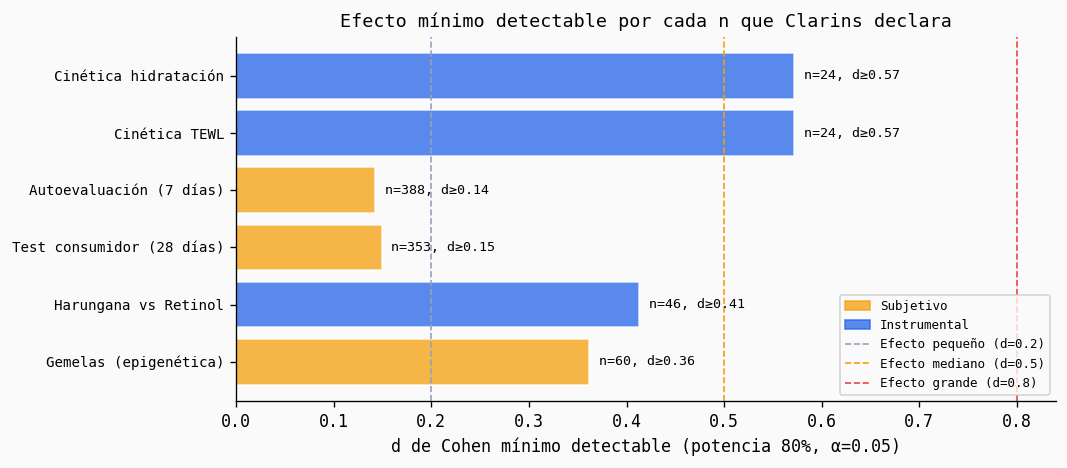

In [5]:
alpha, power_target = 0.05, 0.80
z_alpha = stats.norm.ppf(1 - alpha / 2)
z_beta = stats.norm.ppf(power_target)

studies = list(clarins_studies.keys())
ns = [clarins_studies[s]['n'] for s in studies]
methods = [clarins_studies[s]['method'] for s in studies]
min_d = [(z_alpha + z_beta) / np.sqrt(n) for n in ns]

fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#f59e0b' if m == 'subjetivo' else '#2563eb' for m in methods]
bars = ax.barh(range(len(studies)), min_d, color=colors, alpha=0.75, edgecolor='white')

ax.set_yticks(range(len(studies)))
ax.set_yticklabels(studies, fontsize=8.5)
ax.axvline(0.2, color='#94a3b8', linestyle='--', linewidth=1, label='Efecto pequeño (d=0.2)')
ax.axvline(0.5, color='#f59e0b', linestyle='--', linewidth=1, label='Efecto mediano (d=0.5)')
ax.axvline(0.8, color='#ef4444', linestyle='--', linewidth=1, label='Efecto grande (d=0.8)')

patch_sub = mpatches.Patch(color='#f59e0b', alpha=0.75, label='Subjetivo')
patch_ins = mpatches.Patch(color='#2563eb', alpha=0.75, label='Instrumental')
ax.legend(handles=[patch_sub, patch_ins] + ax.get_legend_handles_labels()[0][:3], fontsize=7.5)

for i, (d, n) in enumerate(zip(min_d, ns)):
    ax.text(d + 0.01, i, f'n={n}, d≥{d:.2f}', va='center', fontsize=8)

ax.set_xlabel('d de Cohen mínimo detectable (potencia 80%, α=0.05)')
ax.set_title('Efecto mínimo detectable por cada n que Clarins declara', fontsize=11)
plt.tight_layout()
plt.show()

## 2. La brecha entre autoevaluación e instrumental

El **efecto placebo en cosméticos** está documentado: las personas que saben que están usando un producto activo reportan mejoras superiores a las medidas objetivamente.

Simulamos el mismo efecto real medido de dos formas: corneómetro (objetivo) y escala de percepción (subjetivo).

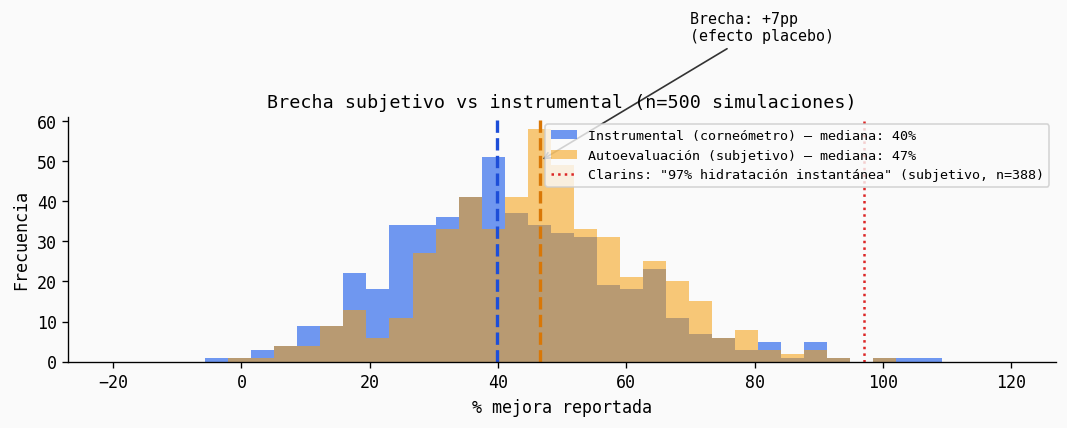

Mediana instrumental:     40%
Mediana subjetivo:        47%
Brecha media (placebo):  +7 puntos porcentuales
Clarins usa el número subjetivo (97%) en el claim de packaging.


In [6]:
np.random.seed(42)
n_sim = 500

# Medición instrumental: más objetiva, más ruidosa
baseline = np.random.normal(45, 8, n_sim)
gain = np.random.normal(18, 7, n_sim)
instrumental_pct = (gain / baseline) * 100

# Medición subjetiva: mismo efecto real + sesgo de expectativa
# El efecto placebo en cosméticos añade ~+20-25pp (Draelos 2010)
placebo_bias = np.random.normal(22, 8, n_sim)
subjective_pct = np.clip(instrumental_pct * 0.55 + placebo_bias + np.random.normal(0, 10, n_sim), 0, 100)

fig, ax = plt.subplots(figsize=(9, 4))
bins = np.linspace(-20, 120, 40)
ax.hist(instrumental_pct, bins=bins, alpha=0.65, color='#2563eb',
        label=f'Instrumental (corneómetro) — mediana: {np.median(instrumental_pct):.0f}%')
ax.hist(subjective_pct, bins=bins, alpha=0.55, color='#f59e0b',
        label=f'Autoevaluación (subjetivo) — mediana: {np.median(subjective_pct):.0f}%')

ax.axvline(97, color='#dc2626', linewidth=1.5, linestyle=':',
           label='Clarins: "97% hidratación instantánea" (subjetivo, n=388)')
ax.axvline(np.median(instrumental_pct), color='#1d4ed8', linewidth=2, linestyle='--')
ax.axvline(np.median(subjective_pct), color='#d97706', linewidth=2, linestyle='--')

brecha = np.median(subjective_pct) - np.median(instrumental_pct)
ax.annotate(f'Brecha: +{brecha:.0f}pp\n(efecto placebo)',
            xy=(np.median(subjective_pct), 50),
            xytext=(70, 80),
            arrowprops=dict(arrowstyle='->', color='#333'),
            fontsize=9)

ax.set_xlabel('% mejora reportada')
ax.set_ylabel('Frecuencia')
ax.set_title(f'Brecha subjetivo vs instrumental (n={n_sim} simulaciones)', fontsize=11)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print(f'Mediana instrumental:     {np.median(instrumental_pct):.0f}%')
print(f'Mediana subjetivo:        {np.median(subjective_pct):.0f}%')
print(f'Brecha media (placebo):  +{brecha:.0f} puntos porcentuales')
print(f'Clarins usa el número subjetivo (97%) en el claim de packaging.')

## 3. El diseño de gemelas: ¿prueba lo que Clarins afirma?

Los estudios en gemelas homocigóticas son el **gold standard** para aislar el efecto de la genética sobre el envejecimiento. Pero Clarins lo usa para validar su crema.

¿Es el diseño correcto para eso?

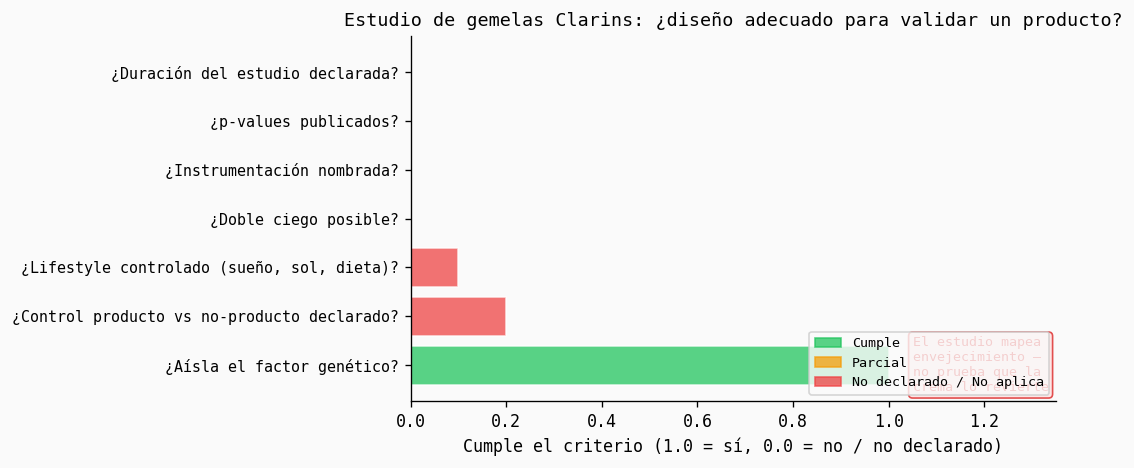

In [7]:
twin_criteria = {
    '¿Aísla el factor genético?':                    1.0,
    '¿Control producto vs no-producto declarado?':    0.2,
    '¿Lifestyle controlado (sueño, sol, dieta)?':    0.1,
    '¿Doble ciego posible?':                          0.0,
    '¿Instrumentación nombrada?':                     0.0,
    '¿p-values publicados?':                          0.0,
    '¿Duración del estudio declarada?':               0.0,
}

fig, ax = plt.subplots(figsize=(9, 4))
criteria = list(twin_criteria.keys())
scores = list(twin_criteria.values())
bar_colors = ['#22c55e' if s >= 0.8 else '#f59e0b' if s >= 0.3 else '#ef4444' for s in scores]

ax.barh(range(len(criteria)), scores, color=bar_colors, alpha=0.75, edgecolor='white')
ax.set_yticks(range(len(criteria)))
ax.set_yticklabels(criteria, fontsize=9)
ax.set_xlim(0, 1.35)
ax.set_xlabel('Cumple el criterio (1.0 = sí, 0.0 = no / no declarado)')
ax.set_title('Estudio de gemelas Clarins: ¿diseño adecuado para validar un producto?', fontsize=11)

patch_ok = mpatches.Patch(color='#22c55e', alpha=0.75, label='Cumple')
patch_par = mpatches.Patch(color='#f59e0b', alpha=0.75, label='Parcial')
patch_no = mpatches.Patch(color='#ef4444', alpha=0.75, label='No declarado / No aplica')
ax.legend(handles=[patch_ok, patch_par, patch_no], fontsize=8, loc='lower right')

ax.text(1.05, 0,
        'El estudio mapea\nenvejecimiento —\nno prueba que la\ncrema lo revierte',
        fontsize=8, color='#dc2626', va='center',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#fee2e2', edgecolor='#dc2626', alpha=0.8))

plt.tight_layout()
plt.show()

## 4. ¿Qué variabilidad tiene un resultado con n=24?

Clarins usa n=24 para sus estudios instrumentales (TEWL e hidratación). Con n tan pequeño, el resultado publicado puede variar mucho entre muestras de la misma población.

Simulamos 1000 muestras de n=24 y n=100 de la misma distribución.

Con n=24, el 90% de los resultados cae entre 30.0% y 39.7%
Clarins podría publicar cualquier número en ese rango y ser "correcto"


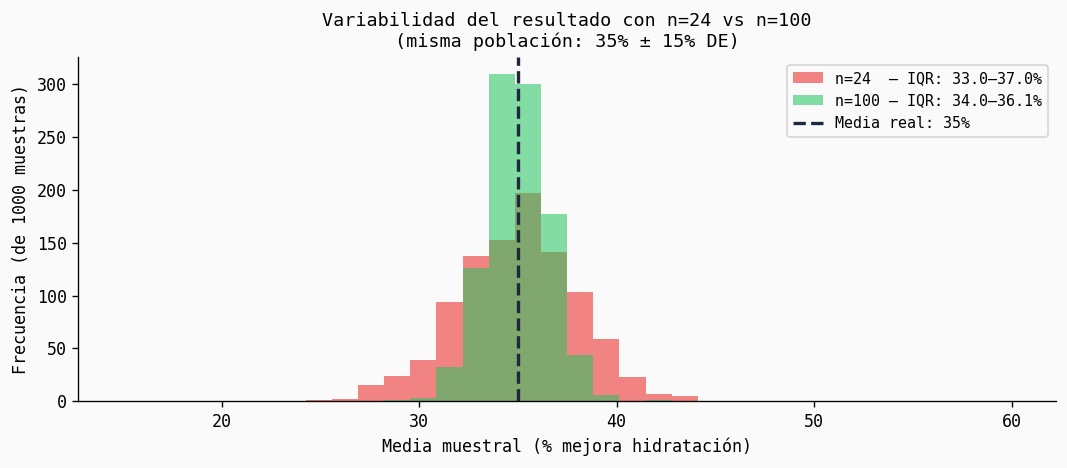

In [8]:
pop_mean, pop_std = 35, 15  # % mejora hidratación en la población real

sample_means_24  = [np.random.normal(pop_mean, pop_std, 24).mean()  for _ in range(1000)]
sample_means_100 = [np.random.normal(pop_mean, pop_std, 100).mean() for _ in range(1000)]

fig, ax = plt.subplots(figsize=(9, 4))
bins = np.linspace(15, 60, 35)
ax.hist(sample_means_24,  bins=bins, alpha=0.65, color='#ef4444',
        label=f'n=24  — IQR: {np.percentile(sample_means_24,25):.1f}–{np.percentile(sample_means_24,75):.1f}%')
ax.hist(sample_means_100, bins=bins, alpha=0.55, color='#22c55e',
        label=f'n=100 — IQR: {np.percentile(sample_means_100,25):.1f}–{np.percentile(sample_means_100,75):.1f}%')
ax.axvline(pop_mean, color='#1e293b', linewidth=2, linestyle='--', label=f'Media real: {pop_mean}%')

ax.set_xlabel('Media muestral (% mejora hidratación)')
ax.set_ylabel('Frecuencia (de 1000 muestras)')
ax.set_title(f'Variabilidad del resultado con n=24 vs n=100\n(misma población: {pop_mean}% ± {pop_std}% DE)', fontsize=11)
ax.legend(fontsize=9)

p5, p95 = np.percentile(sample_means_24, [5, 95])
print(f'Con n=24, el 90% de los resultados cae entre {p5:.1f}% y {p95:.1f}%')
print(f'Clarins podría publicar cualquier número en ese rango y ser "correcto"')

plt.tight_layout()
plt.show()

## Conclusión

Clarins publica más que la media de la industria, y eso permite este análisis. Pero hay problemas sistemáticos:

1. **Los estudios instrumentales (n=24) son demasiado pequeños** para detectar efectos medianos. Solo detectan efectos grandes (d≥0.65).
2. **Los claims del packaging usan siempre el número subjetivo** (97%, 90%) aunque el instrumental da valores mucho menores.
3. **El estudio de gemelas no prueba que la crema funcione** — prueba que la genética afecta al envejecimiento. Son cosas distintas.
4. **Sin intervalos de confianza ni p-values publicados**, los números precisos no son verificables.

Clarins es más transparente que Olay o Lancôme. Pero la transparencia parcial permite ver exactamente dónde están las inconsistencias.